In [10]:
import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Reading in barcode activities and reads

In [7]:
# Activities for all observed barcodes
bc_activ_thresh_0 = pd.read_csv("../output/testgfp1_activity_SK_barcoded_thresh_0.csv")
bc_activ_thresh_0 = bc_activ_thresh_0.rename(columns = {"Unnamed: 0" : "BC"})
bc_activ_thresh_0

,BC,0,1,2,3,4,5,6,7,Activity
0,CCCAGATGAGC,0.117975,0.224031,0.215206,0.143037,0.199060,0.080684,0.018176,0.001832,533.918020
1,TACCGATCAAA,0.503331,0.187267,0.199933,0.000492,0.108488,0.000000,0.000489,0.000000,269.737318
2,TCCGTCTCCTG,0.587273,0.223130,0.040473,0.134213,0.000000,0.014911,0.000000,0.000000,237.183992
3,ACCGGCTACCC,0.258315,0.274496,0.219647,0.161630,0.046067,0.021804,0.009502,0.008539,397.941356
4,TCTGTTGTAAC,0.413415,0.375553,0.120608,0.081586,0.005886,0.002696,0.000110,0.000144,238.140026
...,...,...,...,...,...,...,...,...,...,...
1536432,TGTTGACGGGC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000
1536433,CCGCGTCGATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000
1536434,ACGAACACACT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000
1536435,CCCGAGTAAGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000


In [8]:
# Adding reads to BC 
bc_reads = pd.read_csv('../output/testgfp1_readsseries_SK_barcoded_thresh_0.csv').rename(columns = {"Unnamed: 0" : "BC", "0" : "reads"})
bc_activ_reads = pd.merge(bc_activ_thresh_0, bc_reads)
bc_activ_reads

,BC,0,1,2,3,4,5,6,7,Activity,reads
0,CCCAGATGAGC,0.117975,0.224031,0.215206,0.143037,0.199060,0.080684,0.018176,0.001832,533.918020,107363.0
1,TACCGATCAAA,0.503331,0.187267,0.199933,0.000492,0.108488,0.000000,0.000489,0.000000,269.737318,1788.0
2,TCCGTCTCCTG,0.587273,0.223130,0.040473,0.134213,0.000000,0.014911,0.000000,0.000000,237.183992,7998.0
3,ACCGGCTACCC,0.258315,0.274496,0.219647,0.161630,0.046067,0.021804,0.009502,0.008539,397.941356,2297252.0
4,TCTGTTGTAAC,0.413415,0.375553,0.120608,0.081586,0.005886,0.002696,0.000110,0.000144,238.140026,39498.0
...,...,...,...,...,...,...,...,...,...,...,...
1536432,TGTTGACGGGC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,1.0
1536433,CCGCGTCGATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,1.0
1536434,ACGAACACACT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,1.0
1536435,CCCGAGTAAGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,1.0


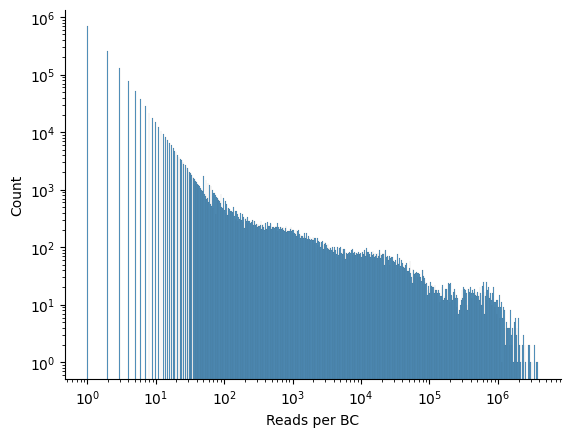

In [11]:
# How many reads per BC?
ax = sns.histplot(bc_activ_reads["reads"], log_scale=True)
ax.set_yscale('log')
plt.xlabel("Reads per BC")
sns.despine()

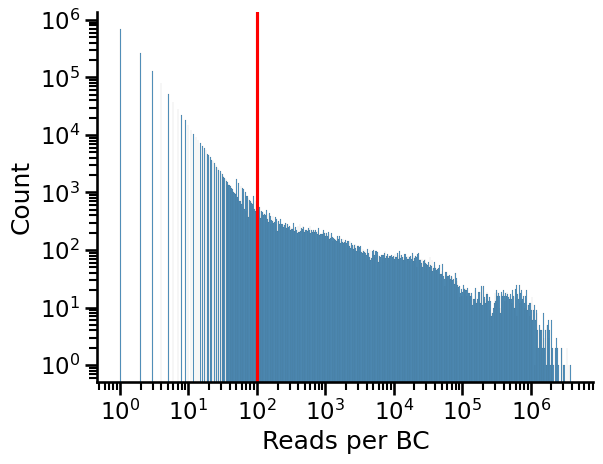

In [234]:
# How many reads per BC?
ax = sns.histplot(bc_activ_reads["reads"], log_scale=True)
ax.set_yscale('log')
ax.axvline(100, color = 'red')
plt.xlabel("Reads per BC")
sns.despine()

In [186]:
# Filtering to only BCs with over 100 reads
bc_activ_reads_over_100 = bc_activ_reads[bc_activ_reads["reads"] > 100]
bc_activ_reads_over_100

,BC,0,1,2,3,4,5,6,7,Activity,reads
0,CCCAGATGAGC,0.117975,0.224031,0.215206,0.143037,0.199060,0.080684,0.018176,0.001832,533.918020,107363.0
1,TACCGATCAAA,0.503331,0.187267,0.199933,0.000492,0.108488,0.000000,0.000489,0.000000,269.737318,1788.0
2,TCCGTCTCCTG,0.587273,0.223130,0.040473,0.134213,0.000000,0.014911,0.000000,0.000000,237.183992,7998.0
3,ACCGGCTACCC,0.258315,0.274496,0.219647,0.161630,0.046067,0.021804,0.009502,0.008539,397.941356,2297252.0
4,TCTGTTGTAAC,0.413415,0.375553,0.120608,0.081586,0.005886,0.002696,0.000110,0.000144,238.140026,39498.0
...,...,...,...,...,...,...,...,...,...,...,...
1423507,ACCTGGGGACT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,140.0
1423657,TGTGTTAAATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,345.0
1424412,CAAAGACAATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,135.0
1425924,TAAGCCGTTTC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,116.0


# 2. Mapping BCs to ADs

In [187]:
# Adding AD sequences
# bc_dict = pd.read_csv("../output/sog1_lib1+2map_EC20250403.csv").T
# bc_dict = bc_dict.reset_index().rename(columns = {"index" : "BC", 0 : "AD"})
# bc_dict["ProteinSeq"] = bc_dict["AD"].apply(lambda s: str(Seq(s).translate()))
# bc_dict

In [188]:
# Only keeping BCs with > 100 reads and mappable
mapped_bcs_over_100_reads = pd.merge(bc_activ_reads_over_100, bc_dict, on = "BC")
mapped_bcs_over_100_reads

,BC,0,1,2,3,4,5,6,7,Activity,reads,AD,ProteinSeq
0,TCCGTCTCCTG,0.587273,0.223130,0.040473,0.134213,0.000000,0.014911,0.000000,0.000000,237.183992,7998.0,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,QALSLCNNLLGSQNRQQNTNSGSLKNKQPCIANYAHLGPQ
1,TCTGTTGTAAC,0.413415,0.375553,0.120608,0.081586,0.005886,0.002696,0.000110,0.000144,238.140026,39498.0,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,LEHGLENGAAAALDDKEEQEKDRDNENQGEEDPTWFDSGS
2,TAGTTCGCCCT,0.268430,0.313989,0.252776,0.035045,0.082460,0.047299,0.000000,0.000000,342.707399,15076.0,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,TWEPDFDSGSQFILNSQQLVEADCSGETLLRSLLNQNEDD
3,TGTCCGCTGGC,0.314362,0.307762,0.198152,0.128149,0.024473,0.015616,0.006489,0.004997,335.197961,1019070.0,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,DIFAAVAPAADPDDPKLDDPEPRNAVRICADAHIAADFVA
4,GGCTTCGTGAA,0.486651,0.378026,0.097805,0.021041,0.003404,0.004646,0.005515,0.002912,244.965320,123719.0,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,LAHGLANGAKAMLAAKAAQEKARDNANQGAAAPTWFASGS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18819,ACTCCAGTCGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,214.0,CAGAAAGCTGTCTTTGCTAGATCTAGAATTAATCAATATAATGATG...,QKAVFARSRINQYNDEGIGEDIGVDMNHKATACVVYKPGG
18820,ACCTGGGGACT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,140.0,ATTATTTGGCATTTGTTGGCTAAATCTGGTTTGTCTGGTTTGTCTT...,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN
18821,TGTGTTAAATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,345.0,AATACTCCAACTCCACCATCTTTGGTTGATGGTGTTGCTGGTGATG...,NTPTPPSLVDGVAGDEEAFDDLKMFDPFFEELDSIPEAAL
18822,CAAAGACAATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,135.0,GAAGAATTGTTGCCAATTTCTTGGGATTGGGATGCTAATTTGGATA...,EELLPISWDWDANLDIEGGGGVDGLLDTPYHFNPHTDYFY


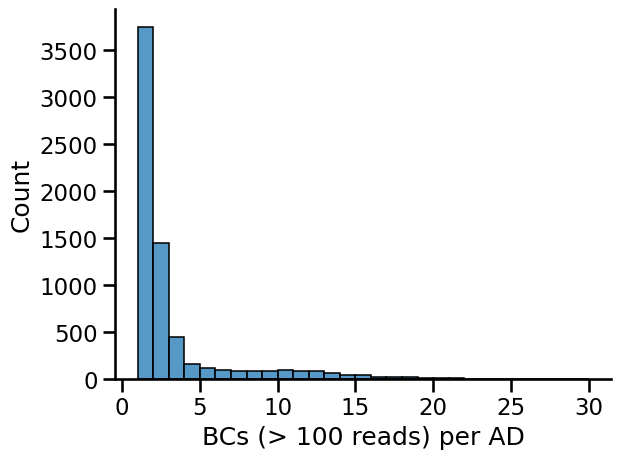

In [212]:
# How many BCs with reads > 100 per AD?
sns.set_context('talk')
sns.histplot(mapped_bcs_over_100_reads["AD"].value_counts(),binwidth = 1)
sns.despine()
plt.xlabel("BCs (> 100 reads) per AD");

# 3. Aggregating to get per AD activity and error

In [224]:
# Now, averaging together activity per AD
AD_activities = mapped_bcs_over_100_reads[["Activity", "ProteinSeq"]].groupby("ProteinSeq").agg([np.mean, np.std, 'count']).reset_index()
AD_activities.columns = ["ProteinSeq", "Activity", "Error", "BC Count"]
AD_activities


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_57448/2797372766.py:2: FutureWarning: The provided callable <function mean at 0x1074a7940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  AD_activities = mapped_bcs_over_100_reads[["Activity", "ProteinSeq"]].groupby("ProteinSeq").agg([np.mean, np.std, 'count']).reset_index()
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_57448/2797372766.py:2: FutureWarning: The provided callable <function std at 0x1074a7a60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  AD_activities = mapped_bcs_over_100_reads[["Activity", "ProteinSeq"]].groupby("ProteinSeq").agg([np.mean, np.std, 'count']).reset_index()


,ProteinSeq,Activity,Error,BC Count
0,AAAAAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,247.596326,NaN,1
1,AAAAAAAACQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2420.236680,NaN,1
2,AAAAAAAAGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,544.103037,NaN,1
3,AAAAAAAANIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,391.240450,NaN,1
4,AAAAAHLGPEDFKRDLEECQAAAADPSNIELDTPPEFRLS,428.387407,192.551180,2
...,...,...,...,...
6788,YSLFDDPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,1627.763143,NaN,1
6789,YSLFDSPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,3249.679912,3714.542390,2
6790,YSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCK,1304.650547,2097.495254,6
6791,YSTGTRKRRKILDDDLGDVRWHKTGRTKPVILDGVQRGCK,2263.458216,1474.154509,2


In [225]:
AD_activities[AD_activities["BC Count"] > 3]

,ProteinSeq,Activity,Error,BC Count
28,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,1235.131365,1016.672973,4
47,AAAHVKLDSFPAGVRFDPSDEELLEHLAAKIGRSSRKPHP,458.621875,230.549201,15
128,AEDFKKDLEECQRLEPTDNTNLELDNTDEFRLSQIEFSQD,647.499278,135.094294,4
131,AEHGAENGAKEMADDKEEQEKDRDNENQGEEDPTAADSGA,538.946766,398.075103,10
132,AEHGAENGAKEMADDKEEQEKDRDNENQGEEDPTAADSGD,628.781469,460.045175,5
...,...,...,...,...
6779,YNTGTRKRRRINTDDADVRWHKTGNTKPVLVDGKHLGCKK,754.332497,1235.014235,11
6781,YPPRDDYHEQPYPVMDTEGNVIGLTDLECDEELLPISWDW,4452.840011,2300.374231,20
6783,YQNGQRKRRRITPTSLKDDTVRWHKTGQTKPVMLNGIQKG,413.411986,377.439871,12
6784,YRIDNSNVLIPWPGLPKGVKFEPTDEDIIEFLEAKCGIGG,1487.211992,1238.931774,10


In [226]:
AD_activities["BC Count"].value_counts()

BC Count
1     3744
2     1447
3      443
4      160
5      115
6       99
10      93
9       91
7       91
8       91
11      83
12      82
13      61
14      46
15      41
16      24
18      21
17      20
20      10
19       9
21       7
22       5
27       2
26       2
23       2
24       2
25       1
30       1
Name: count, dtype: int64

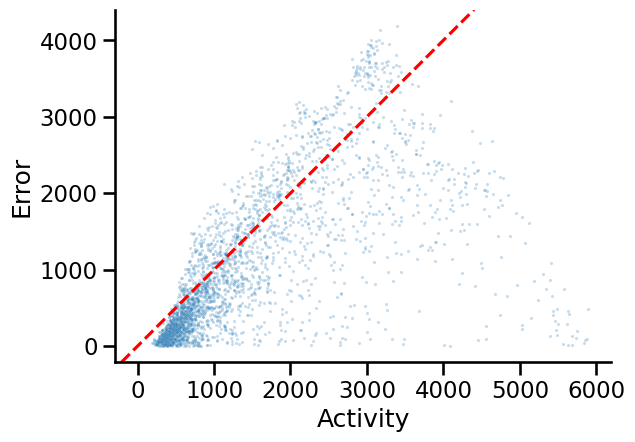

In [227]:
ax = sns.scatterplot(data = AD_activities, x = "Activity", y = "Error", alpha = 0.25, s = 5)
ax.axline((0, 0), slope=1, color = 'red', linestyle  = 'dashed')
plt.gca().set_aspect('equal', adjustable='box')
sns.despine()

In [232]:
AD_activities = AD_activities.rename(columns = {"Activity" : "Activity_S3_1"})
AD_activities.to_csv("../output/SK_recalc_scores.csv")
AD_activities

,ProteinSeq,Activity_S3_1,Error,BC Count
0,AAAAAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,247.596326,NaN,1
1,AAAAAAAACQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2420.236680,NaN,1
2,AAAAAAAAGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,544.103037,NaN,1
3,AAAAAAAANIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,391.240450,NaN,1
4,AAAAAHLGPEDFKRDLEECQAAAADPSNIELDTPPEFRLS,428.387407,192.551180,2
...,...,...,...,...
6788,YSLFDDPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,1627.763143,NaN,1
6789,YSLFDSPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,3249.679912,3714.542390,2
6790,YSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCK,1304.650547,2097.495254,6
6791,YSTGTRKRRKILDDDLGDVRWHKTGRTKPVILDGVQRGCK,2263.458216,1474.154509,2


In [238]:
len(AD_activities[~AD_activities["Error"].isna()])

3049

In [237]:
len(AD_activities[~AD_activities["Error"].isna()]) / len(AD_activities)

0.44884439864566467

In [239]:
old_scores = pd.read_csv("../output/Sog1_library2_activities_with_reads_errors_SK.csv")
old_scores

,Unnamed: 0,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std,unweighted_std,weighted_std
0,0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1106.567900,925.703811,608.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1016.135856,127.890224,2082.150650,1083.892916
1,1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1406.746740,1424.548173,44353.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1415.647457,12.587514,1872.079725,111.075921
2,2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1393.949144,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1282.071136,158.219396,217.073053,152.773383
3,3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.112716,267.611412,5086.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.362064,10.961077,369.847855,25.401184
4,4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4090.212610,3163.539743,170.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3626.876176,655.256668,2599.372371,1318.801372
...,...,...,...,...,...,...,...,...,...,...,...
12311,12311,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2353.906760,2111.813429,121.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2232.860095,171.185836,NaN,0.000000
12312,12312,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4429.235054,4873.732571,6361.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4651.483812,314.307209,2516.165528,302.142160
12313,12313,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1697.233176,1569.322449,814.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1633.277813,90.446543,1777.750662,1077.121072
12314,12314,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1894.661621,2360.015854,68.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2127.338737,329.055134,1857.022769,1313.113393


In [241]:
score_comparison = pd.merge(old_scores, AD_activities, left_on = "AAseq", right_on = "ProteinSeq", suffixes=("_old", "_new"))
score_comparison

,Unnamed: 0,ArrayDNA,Activity_S3_1_old,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std,unweighted_std,weighted_std,ProteinSeq,Activity_S3_1_new,Error,BC Count
0,0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1106.567900,925.703811,608.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1016.135856,127.890224,2082.150650,1083.892916,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,848.404455,751.057261,2
1,1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1406.746740,1424.548173,44353.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1415.647457,12.587514,1872.079725,111.075921,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1403.447594,NaN,1
2,3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.112716,267.611412,5086.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.362064,10.961077,369.847855,25.401184,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,277.496358,NaN,1
3,4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4090.212610,3163.539743,170.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3626.876176,655.256668,2599.372371,1318.801372,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,5010.407644,NaN,1
4,7,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,3456.328238,3818.736164,240670.0,224489.0,KQDLEKCHELGLSDADFRLDQIEFDQDSCTAAWAGGNMLD,3637.532201,256.261102,1398.022962,116.699224,KQDLEKCHELGLSDADFRLDQIEFDQDSCTAAWAGGNMLD,1942.639008,2124.098669,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6788,12309,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGATCCATTGT...,1321.900203,1332.158645,64050.0,70387.0,FDSPDVAESFETDPLFANADADLAGQDAWFSLFPSISGGE,1327.029424,7.253813,2937.871809,1726.277229,FDSPDVAESFETDPLFANADADLAGQDAWFSLFPSISGGE,3190.909291,3628.341353,2
6789,12310,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGCTCCATTGT...,604.033292,2901.303690,27209.0,581.0,FDSPDVAESFETAPLFANADADLAGQDAWFSLFPSISGGE,1752.668491,1624.415476,1917.937790,388.377429,FDSPDVAESFETAPLFANADADLAGQDAWFSLFPSISGGE,1456.766816,1752.499817,3
6790,12312,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4429.235054,4873.732571,6361.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4651.483812,314.307209,2516.165528,302.142160,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4437.323484,NaN,1
6791,12313,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1697.233176,1569.322449,814.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1633.277813,90.446543,1777.750662,1077.121072,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1370.305692,921.431303,3


Text(0.05, 0.95, 'Pearson r = 0.91')

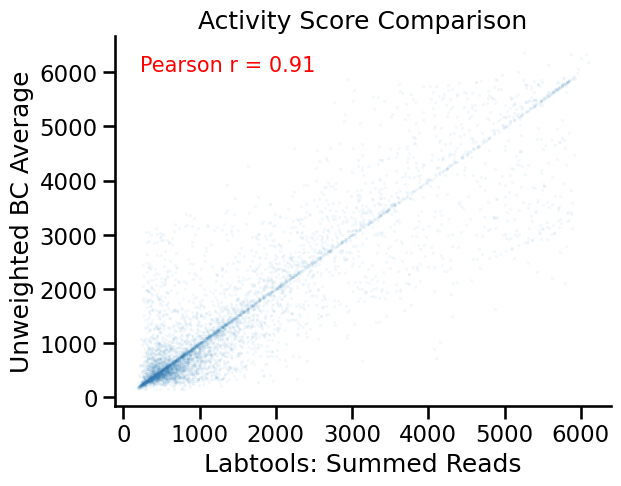

In [259]:
sns.scatterplot(data = score_comparison, x = "Activity_S3_1_old", y = "Activity_S3_1_new", s= 5, alpha = 0.05)
sns.despine()
plt.xlabel("Labtools: Summed Reads")
plt.ylabel("Unweighted BC Average")
plt.title("Activity Score Comparison")

from scipy.stats import pearsonr

# Calculate Pearson correlation
x = score_comparison["Activity_S3_1_old"]
y = score_comparison["Activity_S3_1_new"]
pearson_corr, _ = pearsonr(x, y)
# Add Pearson correlation as text
plt.text(0.05, 0.95, f"Pearson r = {pearson_corr:.2f}", transform=plt.gca().transAxes, fontsize='small', verticalalignment='top', color = 'red')
